# Problem Statement

## Customer Churn Prediction

Customer churn is a critical challenge for subscription-based businesses such as telecommunications providers. Acquiring new customers is typically more expensive than retaining existing ones, making churn prediction a valuable tool for improving customer retention strategies.

The goal of this project is to analyze customer behavior and build a predictive model that identifies customers who are likely to churn. By understanding the key factors driving churn, companies can proactively target at-risk customers with retention strategies.

In this project, I use a Telco customer dataset containing demographic information, account details, service subscriptions, and billing data to explore patterns associated with churn and develop a predictive model.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Data set 

The dataset contains 7,043 customers and includes information about:
- Customer demographics (e.g., gender, senior citizen status)
- Account information (e.g., tenure, contract type)
- Services subscribed to (e.g., internet service, streaming services)
- Billing details (e.g., monthly charges, payment method)
- Target variable: Churn, indicating whether the customer left the company.
The dataset consists of a mix of:
- Numerical features
- Binary categorical variables
- Multi-category categorical variables

## 1. Load Raw Data

In [2]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = df.drop("customerID", axis=1)

# Exploratory Data Analysis (EDA)

Exploratory data analysis is conducted to better understand customer behavior and identify factors associated with churn.

The analysis focuses on:

- Distribution of the target variable
- Relationship between customer characteristics and churn
- Patterns in service usage
- Impact of contract types and billing structures
- Differences in tenure and monthly charges between churned and retained customers

Understanding these relationships helps guide feature engineering and model development.

## 2. Inspect Structure 

In [3]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 20)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


## 3. Check missing values

In [6]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

No missing values are present in the raw dataset.

In [7]:
# Check if TotalCharges contains whitespace or non-numeric values
invalid_total_charges = pd.to_numeric(df["TotalCharges"], errors="coerce").isna().sum()
print("Invalid TotalCharges entries:", invalid_total_charges)

df[df["TotalCharges"].str.strip() == ""].head()

Invalid TotalCharges entries: 11


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No


Note: The TotalCharges column is stored as an object rather than a numeric type. This is because some entries contain blank strings (whitespace), which prevents pandas from interpreting the column as numeric. These values will be handled and converted properly in the preprocessing notebook.

## 4. Check distrbutions

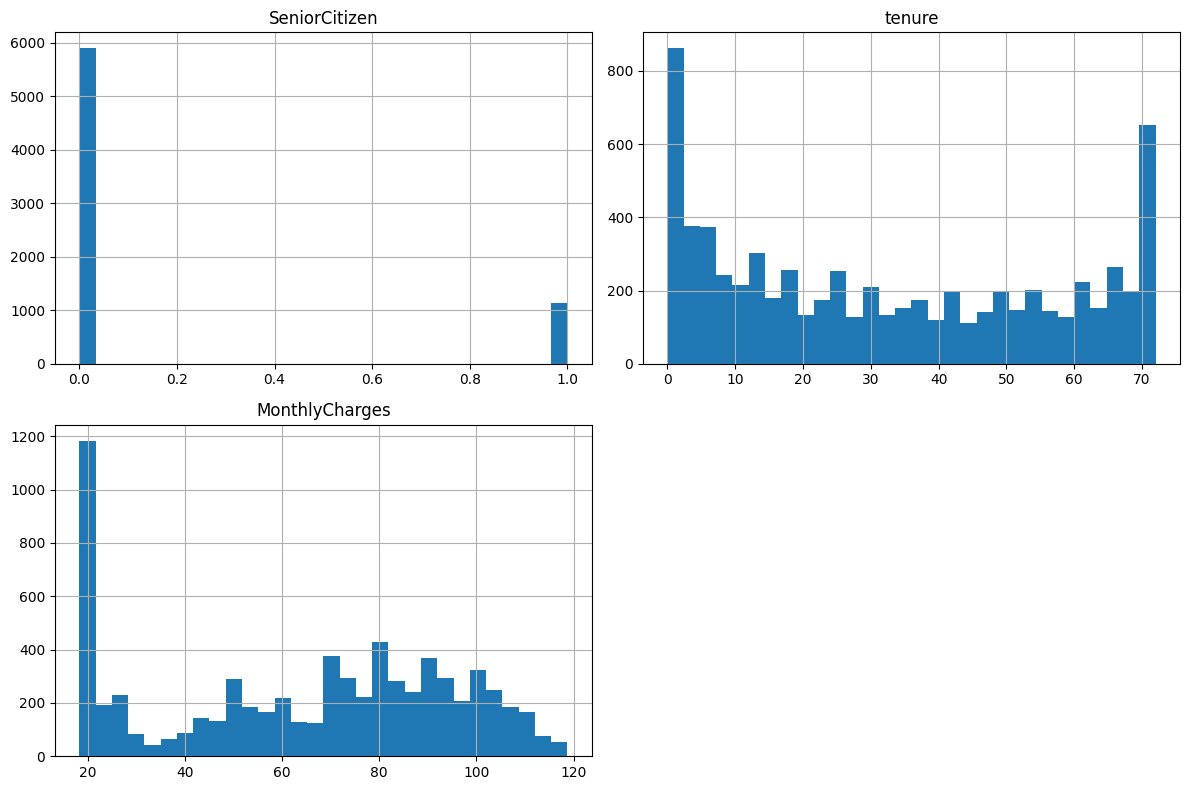

In [8]:
#numerical features
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numeric_cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()


Tenure is heavily right‑skewed, indicating many new customers. Monthly charges appear normally distributed with a slight right tail.

## 5. Target variable distribution

In [ ]:
#Target variable Churn
df["Churn"].value_counts(normalize=True)

#Imbalance dataset



Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

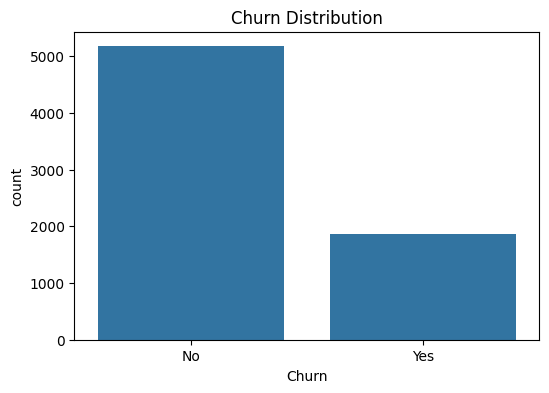

In [ ]:
#Churn figure
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.savefig("../reports/figures/churn_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


The dataset is imbalanced, with only ~27% churners. This will influence model evaluation and may require class weighting.

## 6. Value counts for categorical variables

In [11]:
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())



--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64

--- Dependents ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

--- MultipleLines ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- OnlineSecurity ---
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

--- OnlineBackup ---
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

--- DeviceProtection ---
DeviceProtection
No                     3095
Yes                    2422
No internet service   

## 7. Outlier inspection

In [12]:
df[numeric_cols].describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


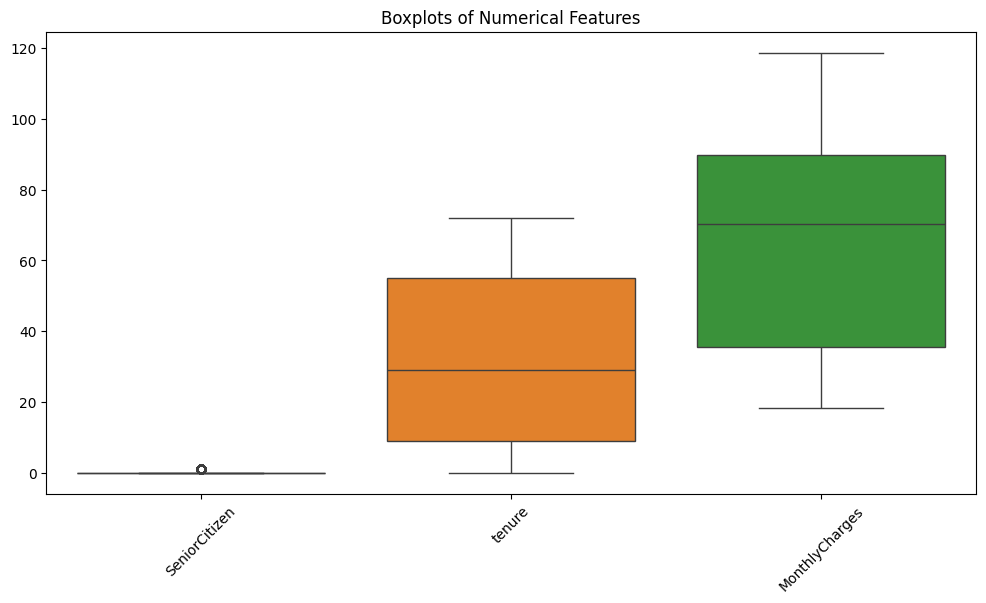

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Features")
plt.show()


## 8. Visualsations

#### 8.1 Monthly Charges vs Churn

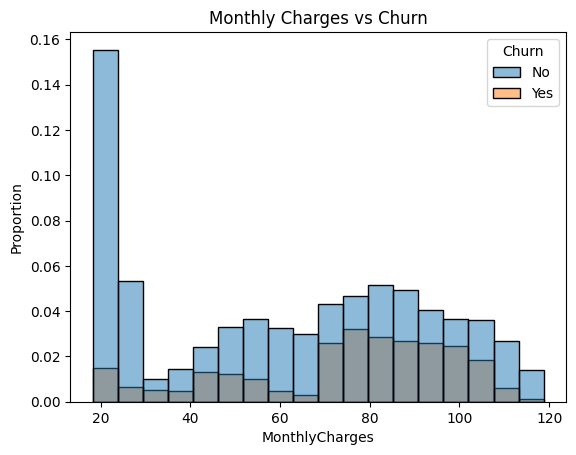

In [14]:
sns.histplot(data=df, x="MonthlyCharges", hue="Churn", stat="proportion")
plt.title("Monthly Charges vs Churn")
plt.show()

Customers with higher monthly charges are more likely to churn.

#### 8.2 Contract Type vs Churn

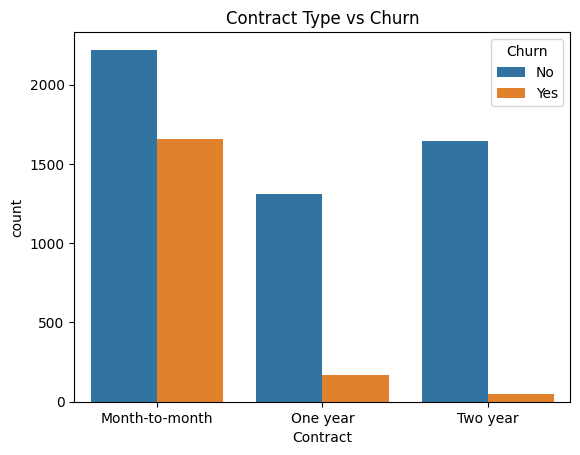

In [15]:
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Contract Type vs Churn")
plt.show()

Customers with longer contracts seem to have a lower churn rate. 

#### 8.3 Tenure vs Churn

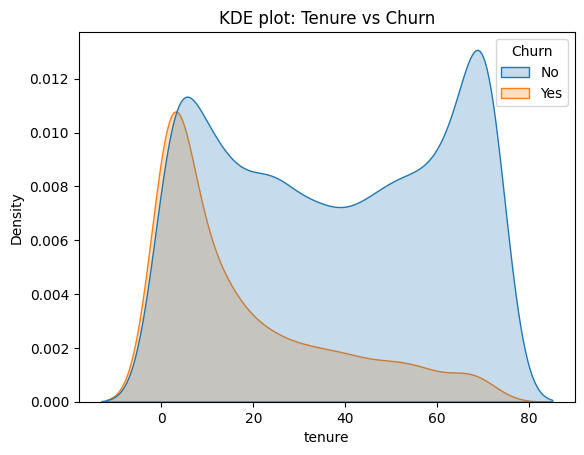

In [16]:
sns.kdeplot(df, x="tenure", hue="Churn", fill=True)
plt.title("KDE plot: Tenure vs Churn")
plt.show()

New customer churn more, Long-term customer rarely leave. The KDE plot for tenure shows two distinct peaks for non‑churners: one among very new customers and another among long‑term customers. The dip in the middle indicates a transition period (roughly 10–40 months) where customers are more likely to churn. This suggests that customers who remain beyond the early months tend to become long‑term loyal customers. 

#### 8.4 Payment Method vs Churn

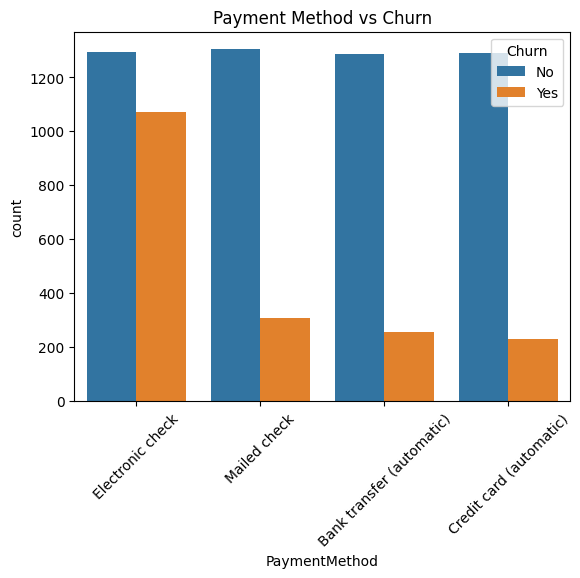

In [17]:
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.xticks(rotation=45)
plt.title("Payment Method vs Churn")
plt.show()


Customers that use electronic check churn more often than with other payment methods.

#### 8.5 Internet Service vs Churn

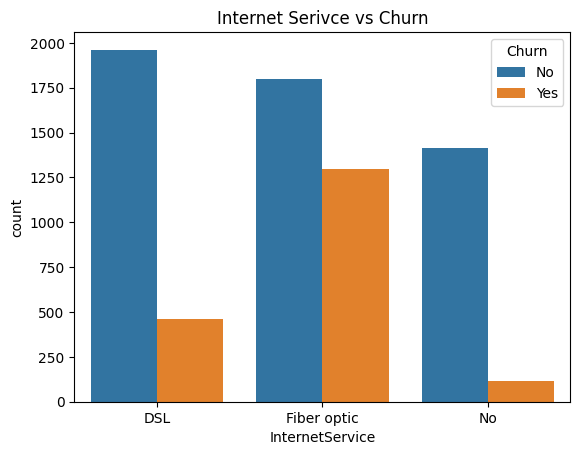

In [18]:
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Internet Serivce vs Churn")
plt.show()

Fiber optic customers churn more than DSL or no‑internet customers.

#### 8.6 Service vs Churn

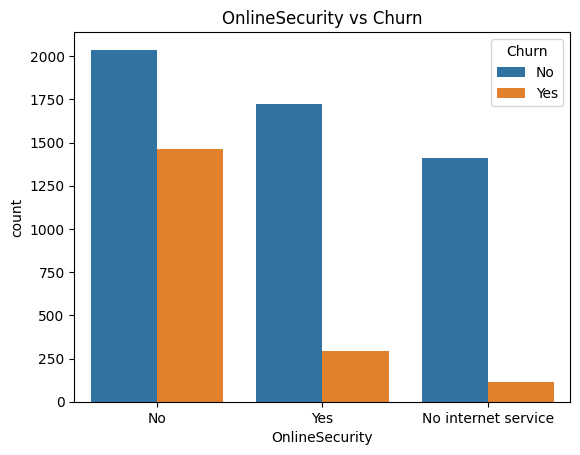

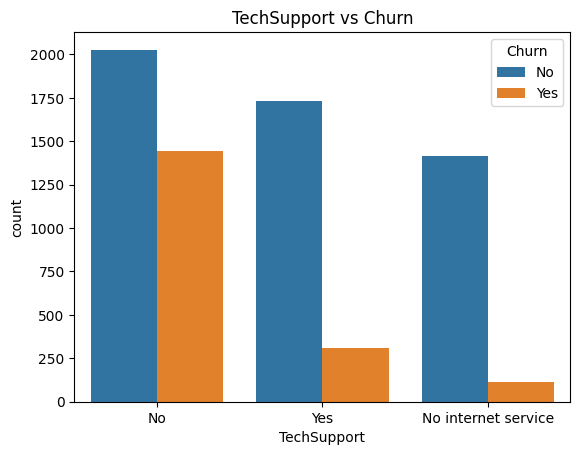

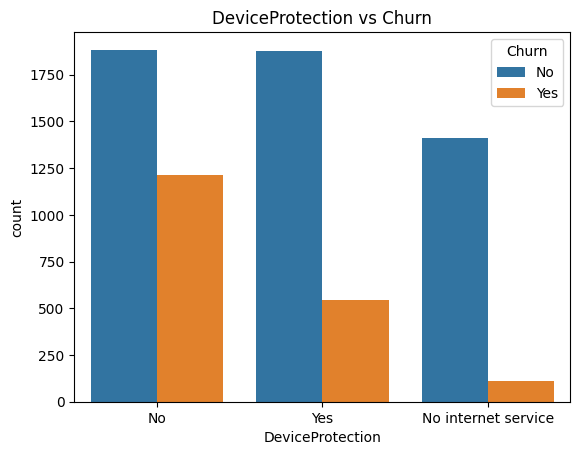

In [19]:
service_cols = ["OnlineSecurity", "TechSupport", "DeviceProtection"]

for col in service_cols:
    sns.countplot(data=df, x=col, hue="Churn")
    plt.title(f"{col} vs Churn")
    plt.show()


Customers without security/tech support churn more.

#### 8.7 Monthy Charges vs Tenure (by Churn)

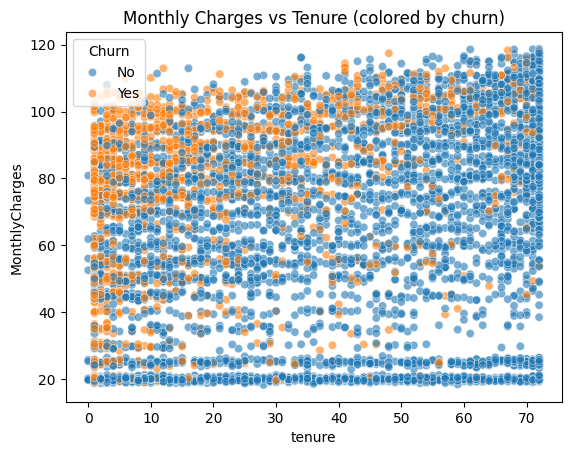

In [20]:
sns.scatterplot(data=df, x="tenure", y="MonthlyCharges", hue="Churn", alpha=0.6)
plt.title("Monthly Charges vs Tenure (colored by churn)")
plt.show()

High‑charge + low‑tenure customers are the most likely to churn.

#### 8.8 Heatmap

C:\Users\marle\AppData\Local\Temp\ipykernel_23908\715005113.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp = df_temp.replace({"Yes": 1, "No": 0})


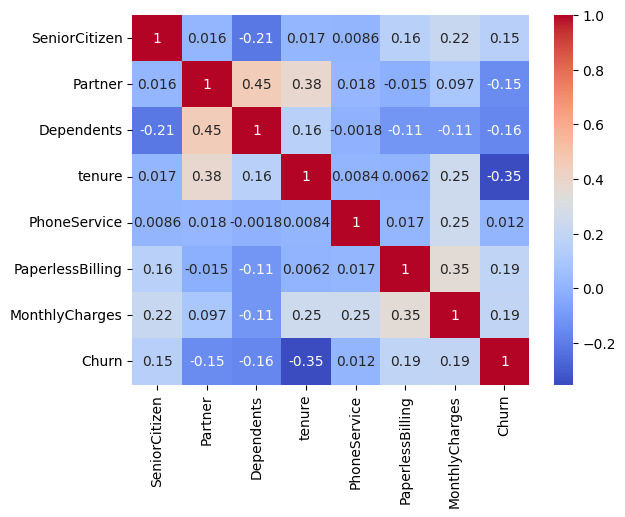

In [21]:
df_temp = df.copy()
df_temp = df_temp.replace({"Yes": 1, "No": 0})

numeric_df = df_temp.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=True)
plt.show()



MonthlyCharges and TotalCharges correlate strongly; tenure correlates negatively with churn.

## 9. Summary of EDA

The exploratory analysis of the Telco Customer Churn dataset reveals several clear patterns that help explain why customers leave the service. The dataset contains 7,043 customers with demographic, service usage, contract, and billing information. Churn is imbalanced, with only about 27% of customers leaving, which will influence model evaluation and may require techniques such as class weighting.

#### Data Quality

- No missing values are present in the raw dataset.

- The TotalCharges column contains blank-string entries for customers with zero tenure, preventing numeric conversion. These will be handled during preprocessing.

#### Numerical Feature Insights

- Tenure is heavily right‑skewed, indicating many new customers.

    - Churners are concentrated at low tenure values.

    - Non‑churners show two peaks: very new customers and long‑term loyal customers, with a churn‑prone “valley” in the middle.

- MonthlyCharges is roughly normally distributed with a slight right tail.

    - Higher monthly charges are strongly associated with higher churn.

- TotalCharges correlates strongly with both tenure and monthly charges, as expected.

#### Categorical Feature Insights

- Contract Type is one of the strongest churn indicators.

    - Month‑to‑month customers churn at much higher rates than one‑year or two‑year contract customers.

- Payment Method shows clear differences.

    - Customers paying via Electronic Check churn significantly more than those using credit cards or bank transfers.

- Internet Service matters.

    - Fiber optic customers churn more frequently than DSL or no‑internet customers.

- Security and Support Services (OnlineSecurity, TechSupport, DeviceProtection) show consistent patterns.

    - Customers without these services churn more often, suggesting that support and protection services may increase retention.

#### Multivariate Patterns

- A scatterplot of MonthlyCharges vs. Tenure shows that churn is concentrated among customers who are both new and paying high charges.

- The correlation heatmap confirms:

    - Strong positive correlation between MonthlyCharges and TotalCharges.

    - Negative correlation between tenure and churn.

    - Moderate positive correlation between MonthlyCharges and churn.